# Análisis Exploratorio y Topológico del Corpus Maestro (TechMind V1)

**Objetivo:** Cuantificar la distribución de clases, la densidad léxica y la procedencia documental del corpus unificado (`DataSetTechmindV1.csv`). Este análisis dictamina los hiperparámetros de truncamiento para los modelos de *Embeddings* y valida la mitigación del sesgo poblacional.

| Artefacto | Ubicación |
|-----------|-----------|
| Dataset | `DataSetTechmindV1.csv` (misma carpeta o `data/` del paquete) |
| Datasheet | `DataSetTechmindV1.DATASHEET.md` |
| Árbol | `DataSetTechmindV1.ARBOL.md` |

**Equipo:** G9-LATAM-Team-46 · TechMind AI · Hackathon ONE G9

Compatible con **Google Colab** (sube el CSV o monta Drive) y con el kernel local `.venv-eda`.


## 1. Entorno e importaciones

En Colab se instalan dependencias con la celda de código. En el venv del proyecto suelen estar ya instaladas.


In [1]:
%matplotlib inline
# Dependencias (descomenta en Colab / entorno limpio)
# %pip install -q "pandas>=2.2.0,<2.3.0" matplotlib seaborn numpy

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
COLOR_PALETTE = "viridis"
print("OK: pandas", pd.__version__)


OK: pandas 2.2.3


## 2. Ingesta y verificación de esquema

Busca el CSV en la carpeta del notebook, en `data/` (paquete de entrega) o en la ruta de trabajo de correcciones.


In [2]:
# Resolver ruta del CSV en varias ubicaciones habituales
CANDIDATES = [
    Path("DataSetTechmindV1.csv"),
    Path("data") / "DataSetTechmindV1.csv",
    Path(r"C:\Team46\G9-LATAM-Team-46\dataset\correcciones\augmented_correciones\trabajo_nuevo\datasets\DataSetTechmindV1.csv"),
    Path(r"C:\Team46\G9-LATAM-Team-46\entregas\DataSetTechmindV1_20260723\data\DataSetTechmindV1.csv"),
]

FILE_PATH = next((p for p in CANDIDATES if p.is_file()), None)
if FILE_PATH is None:
    raise FileNotFoundError(
        "No se encontró DataSetTechmindV1.csv. Colócalo junto al notebook o en data/."
    )

df_master = pd.read_csv(FILE_PATH)
print(f"[CSV] {FILE_PATH.resolve()}")
print(f"Dimensión del tensor tabular: {df_master.shape}")

REQUIRED = [
    "id_fragmento", "titulo_origen", "categoria_l1", "pagina",
    "texto_crudo", "longitud_caracteres", "fecha_extraccion", "hash_texto",
]
missing = [c for c in REQUIRED if c not in df_master.columns]
if missing:
    raise ValueError(f"Faltan columnas del schema DocumentoFragmento: {missing}")

colisiones = len(df_master) - df_master["hash_texto"].nunique()
nulos_totales = int(df_master.isnull().sum().sum())
print(f"Colisiones de Hash (duplicados exactos): {colisiones}")
print(f"Valores nulos en el esquema: {nulos_totales}")
print("Columnas:", list(df_master.columns))
df_master.head(3)


[CSV] C:\Team46\G9-LATAM-Team-46\entregas\DataSetTechmindV1_20260723\notebooks\DataSetTechmindV1.csv
Dimensión del tensor tabular: (668, 8)
Colisiones de Hash (duplicados exactos): 0
Valores nulos en el esquema: 0
Columnas: ['id_fragmento', 'titulo_origen', 'categoria_l1', 'pagina', 'texto_crudo', 'longitud_caracteres', 'fecha_extraccion', 'hash_texto']


,id_fragmento,titulo_origen,categoria_l1,pagina,texto_crudo,longitud_caracteres,fecha_extraccion,hash_texto
0,Redes_y__Fundamentos_de_R_568f47_p001_001,Fundamentos de Redes y TCP.pdf,Redes_y_Comunicaciones,1,6 Interfaces de Programación de Aplicaciones (...,1425,2026-07-23T10:11:00.466220+00:00,44ff810c25cbe49d8fc55eb61799ff3118b92686f5cbc8...
1,Redes_y__Fundamentos_de_R_568f47_p002_002,Fundamentos de Redes y TCP.pdf,Redes_y_Comunicaciones,2,1.1 1.1 El Ecosistema de Códigos de Estado ( S...,2297,2026-07-23T10:11:00.475681+00:00,30bb68cc425db598b02dfdb63d8c2a58d4a285da4d0831...
2,Redes_y__Fundamentos_de_R_568f47_p003_003,Fundamentos de Redes y TCP.pdf,Redes_y_Comunicaciones,3,Código Denominación Explicación Arquitectónica...,1848,2026-07-23T10:11:00.478992+00:00,5aba7f5523eb920a3d2dd6e4c9515bc6b1fa92c482ec2b...


## 3. Auditoría de balance de clases (L1)

Frecuencia absoluta y **ratio max/min** (referencia para `class_weight='balanced'`).


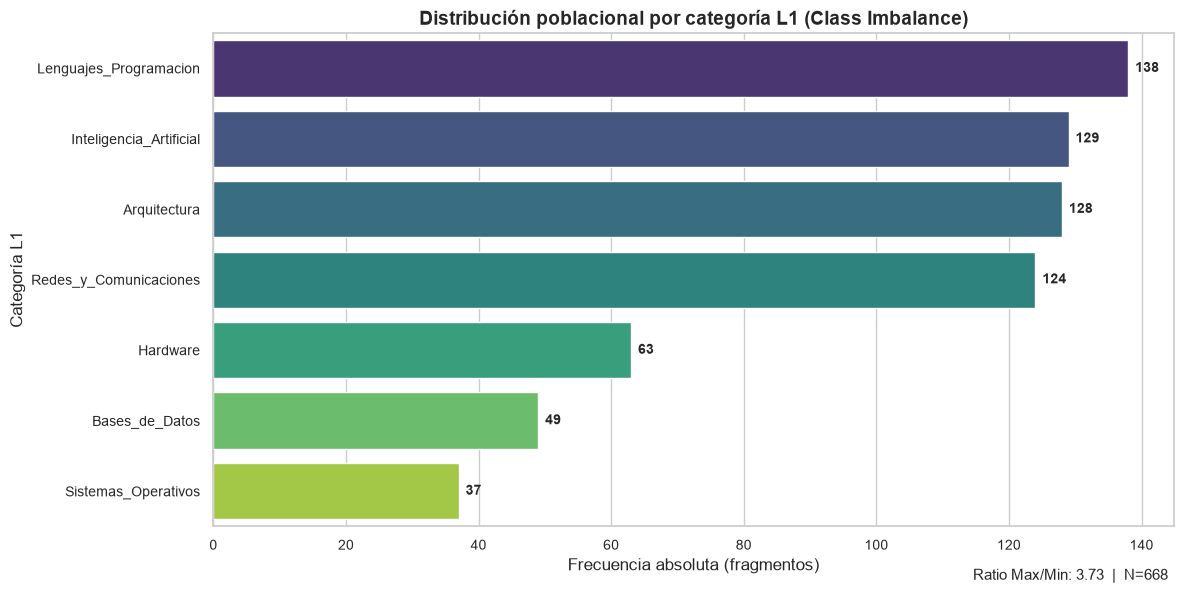

Conteos L1:
categoria_l1
Lenguajes_Programacion     138
Inteligencia_Artificial    129
Arquitectura               128
Redes_y_Comunicaciones     124
Hardware                    63
Bases_de_Datos              49
Sistemas_Operativos         37

Ratio max/min = 3.7297
(Ratio < 5 suele ser manejable con class_weight='balanced' en regresión logística.)


In [3]:
class_counts = df_master["categoria_l1"].value_counts()
ratio_desbalance = class_counts.max() / class_counts.min()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    y=class_counts.index,
    x=class_counts.values,
    hue=class_counts.index,
    palette=COLOR_PALETTE,
    legend=False,
    ax=ax,
)
ax.set_title(
    "Distribución poblacional por categoría L1 (Class Imbalance)",
    fontweight="bold",
)
ax.set_xlabel("Frecuencia absoluta (fragmentos)")
ax.set_ylabel("Categoría L1")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{int(width)}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

plt.figtext(
    0.98,
    0.02,
    f"Ratio Max/Min: {ratio_desbalance:.2f}  |  N={len(df_master)}",
    ha="right",
    fontsize=11,
    bbox={"facecolor": "white", "alpha": 0.85, "pad": 5},
)
plt.tight_layout()
plt.show()

print("Conteos L1:")
print(class_counts.to_string())
print(f"\nRatio max/min = {ratio_desbalance:.4f}")
print("(Ratio < 5 suele ser manejable con class_weight='balanced' en regresión logística.)")


## 4. Densidad longitudinal (calibración de embeddings / truncamiento)

Percentiles de `longitud_caracteres` orientan `max_length` / truncamiento y el riesgo de sesgo por longitud.


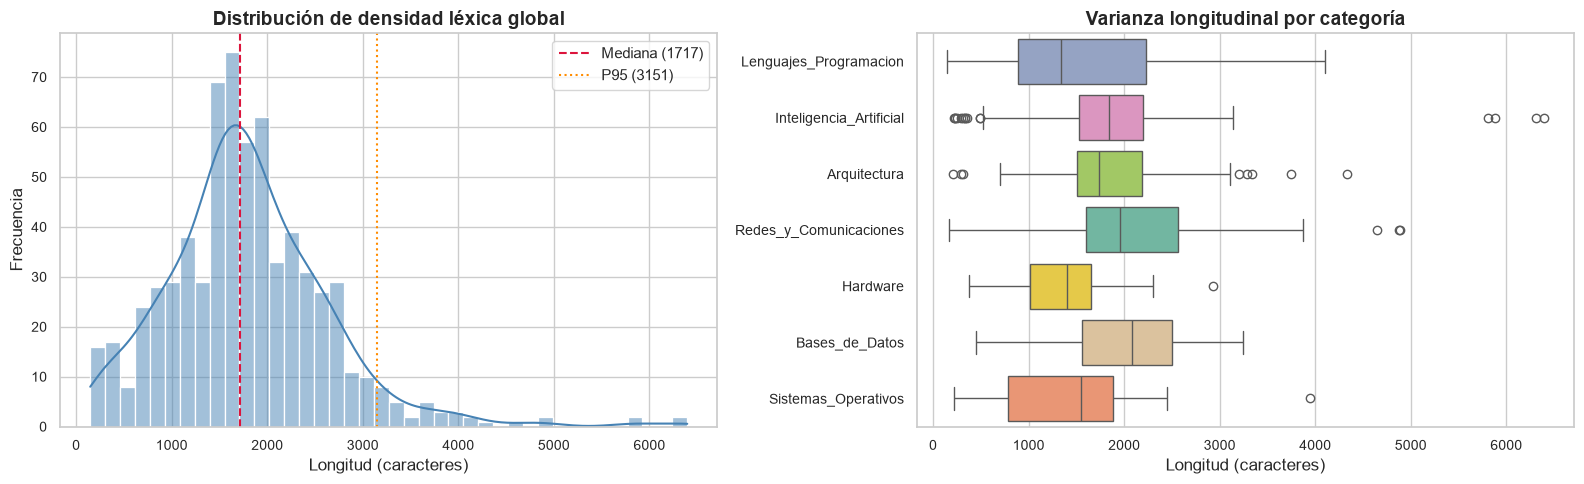

count     668.000000
mean     1792.778443
std       849.135951
min       147.000000
25%      1295.000000
50%      1717.500000
75%      2245.500000
max      6396.000000

P25=1295  P50=1718  P75=2246  P95=3152
Sugerencia embeddings: truncar cerca de P95 en tokens aproximados (~787 tokens si ~4 chars/token) y normalizar L2 en TF-IDF.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    df_master["longitud_caracteres"],
    bins=40,
    kde=True,
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Distribución de densidad léxica global", fontweight="bold")
axes[0].set_xlabel("Longitud (caracteres)")
axes[0].set_ylabel("Frecuencia")

p25, p50, p75, p95 = np.percentile(
    df_master["longitud_caracteres"], [25, 50, 75, 95]
)
axes[0].axvline(p50, color="crimson", linestyle="--", label=f"Mediana ({int(p50)})")
axes[0].axvline(p95, color="darkorange", linestyle=":", label=f"P95 ({int(p95)})")
axes[0].legend()

sns.boxplot(
    data=df_master,
    y="categoria_l1",
    x="longitud_caracteres",
    hue="categoria_l1",
    palette="Set2",
    legend=False,
    order=class_counts.index,
    ax=axes[1],
)
axes[1].set_title("Varianza longitudinal por categoría", fontweight="bold")
axes[1].set_xlabel("Longitud (caracteres)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

stats = df_master["longitud_caracteres"].describe()
print(stats.to_string())
print(f"\nP25={p25:.0f}  P50={p50:.0f}  P75={p75:.0f}  P95={p95:.0f}")
print(
    "Sugerencia embeddings: truncar cerca de P95 en tokens aproximados "
    f"(~{int(p95/4)} tokens si ~4 chars/token) y normalizar L2 en TF-IDF."
)


## 5. Matriz de procedencia documental (linaje)

Clasifica cada fila por **capa de origen**: PDF nativo tipográfico, sintético de balanceo o OCR de imagen.


=== Volumetría por capa ===
capa_origen
PDF_nativo            343
OCR_imagen            287
Sintetico_balanceo     38



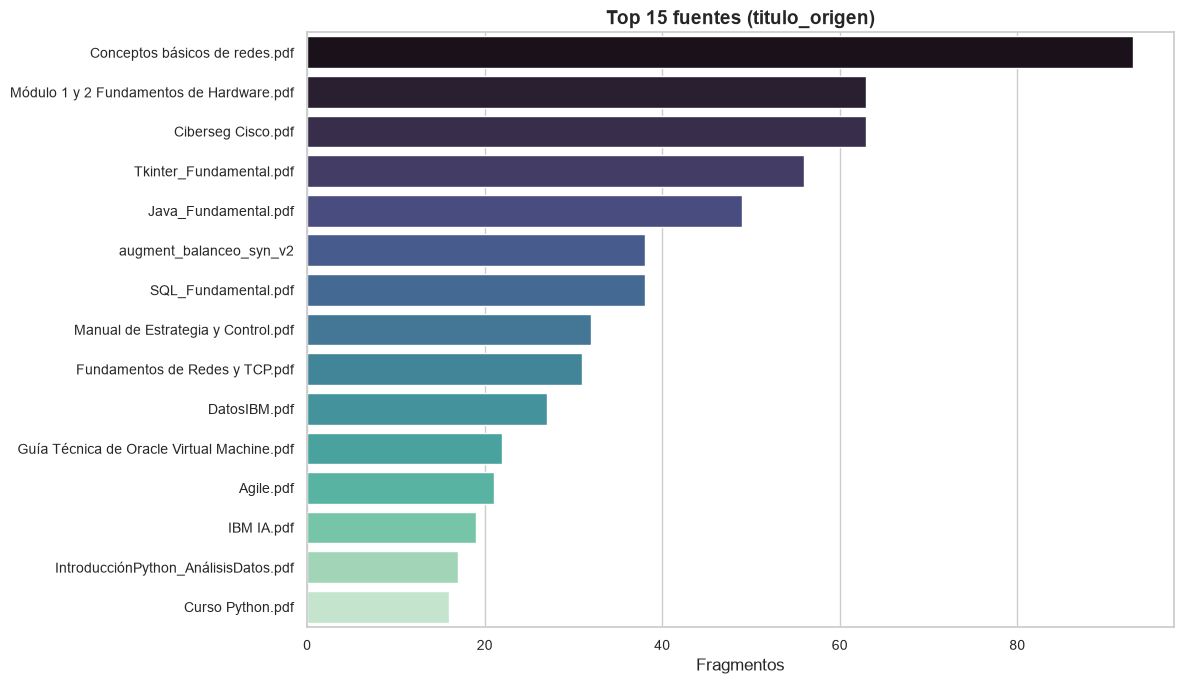

=== Matriz L1 x capa de origen ===
capa_origen              OCR_imagen  PDF_nativo  Sintetico_balanceo
categoria_l1                                                       
Lenguajes_Programacion           16         122                   0
Inteligencia_Artificial          94          35                   0
Arquitectura                     84          32                  12
Redes_y_Comunicaciones           93          31                   0
Hardware                          0          63                   0
Bases_de_Datos                    0          38                  11
Sistemas_Operativos               0          22                  15


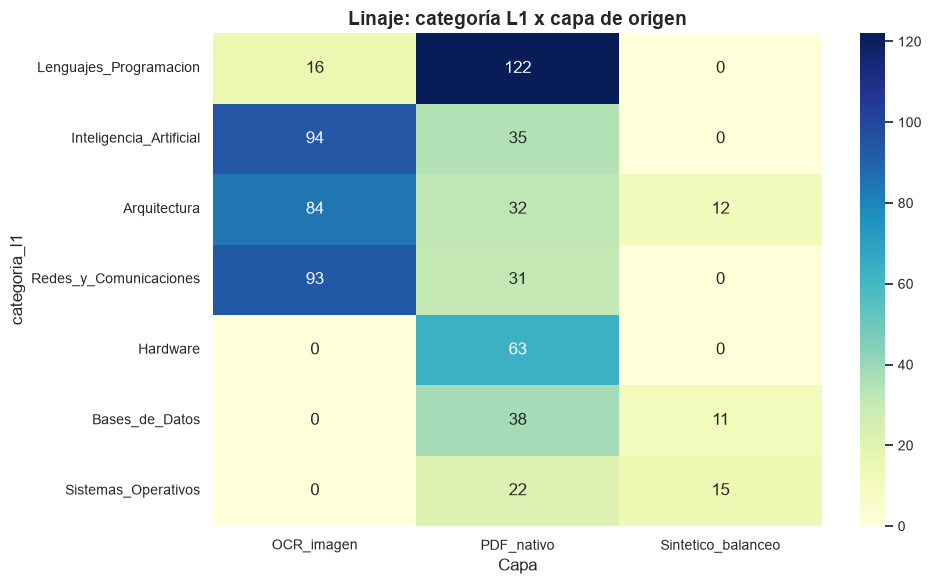

In [5]:
def capa_origen(row) -> str:
    tid = str(row["id_fragmento"])
    tit = str(row["titulo_origen"])
    if tid.startswith("ocr_"):
        return "OCR_imagen"
    if tit.startswith("augment_"):
        return "Sintetico_balanceo"
    return "PDF_nativo"

df_master = df_master.copy()
df_master["capa_origen"] = df_master.apply(capa_origen, axis=1)

print("=== Volumetría por capa ===")
print(df_master["capa_origen"].value_counts().to_string())
print()

top_docs = df_master["titulo_origen"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    y=top_docs.index,
    x=top_docs.values,
    hue=top_docs.index,
    palette="mako",
    legend=False,
    ax=ax,
)
ax.set_title("Top 15 fuentes (titulo_origen)", fontweight="bold")
ax.set_xlabel("Fragmentos")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

ct = pd.crosstab(df_master["categoria_l1"], df_master["capa_origen"])
ct = ct.loc[class_counts.index]
print("=== Matriz L1 x capa de origen ===")
print(ct.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Linaje: categoría L1 x capa de origen", fontweight="bold")
ax.set_xlabel("Capa")
ax.set_ylabel("categoria_l1")
plt.tight_layout()
plt.show()


## 6. Matriz de trazabilidad: fuente documental vs categoria L1

Tabla cruzada 	itulo_origen x categoria_l1 para auditar linaje y detectar fugas de etiqueta (un PDF que alimente varias L1 de forma inesperada).


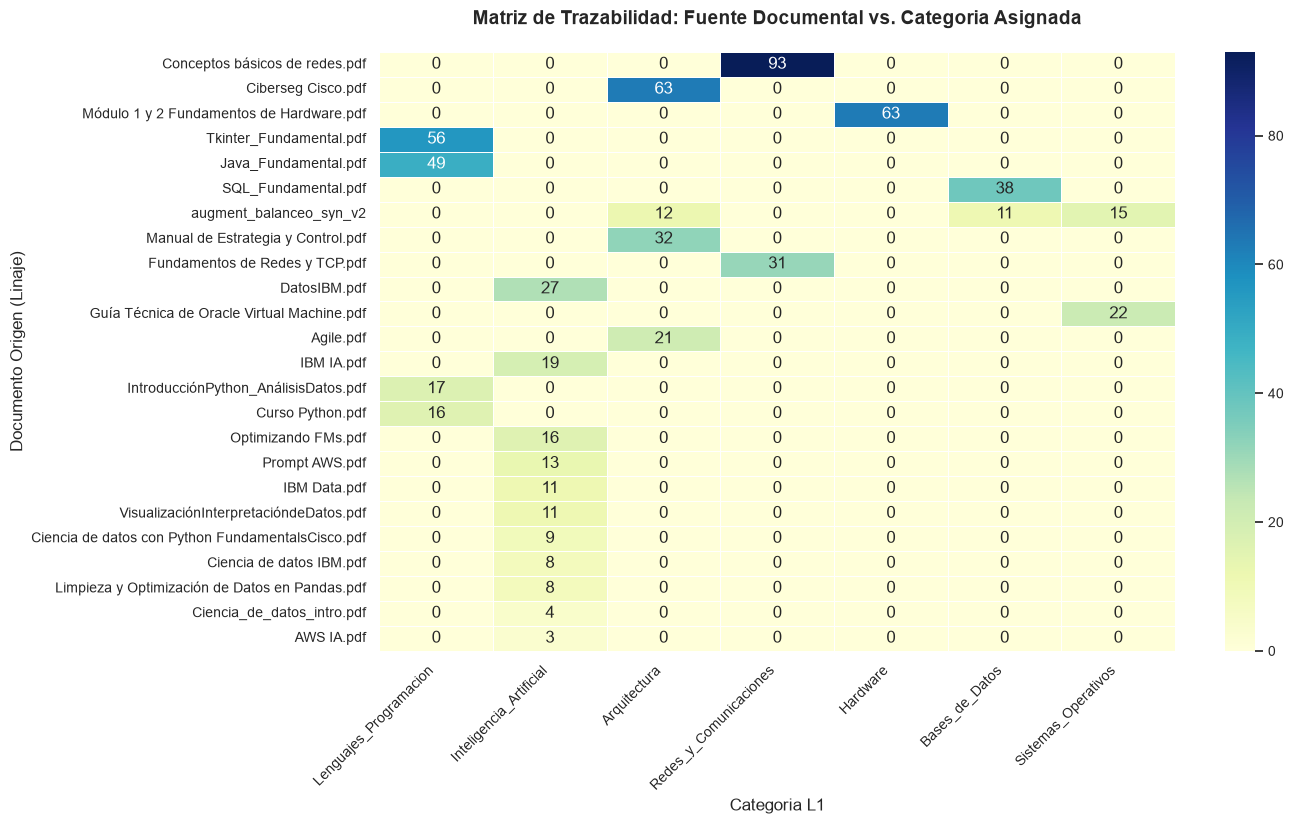

Documentos con mas de una L1 (posible multi-etiqueta o mapeo mixto):
categoria_l1             Lenguajes_Programacion  Inteligencia_Artificial  Arquitectura  Redes_y_Comunicaciones  Hardware  Bases_de_Datos  Sistemas_Operativos
titulo_origen                                                                                                                                                
augment_balanceo_syn_v2                       0                        0            12                       0         0              11                   15


In [6]:
# Tabla cruzada: aportacion de cada documento fuente a las clases L1
contingency_table = pd.crosstab(df_master['titulo_origen'], df_master['categoria_l1'])
# ordenar documentos por volumen total
contingency_table = contingency_table.loc[
    contingency_table.sum(axis=1).sort_values(ascending=False).index
]
# columnas en orden de frecuencia L1
contingency_table = contingency_table.reindex(columns=class_counts.index)

plt.figure(figsize=(14, max(8, 0.35 * len(contingency_table))))
sns.heatmap(
    contingency_table,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    cbar=True,
    linewidths=0.5,
)
plt.title(
    'Matriz de Trazabilidad: Fuente Documental vs. Categoria Asignada',
    fontweight='bold',
    pad=20,
)
plt.xlabel('Categoria L1')
plt.ylabel('Documento Origen (Linaje)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Documentos con mas de una L1 (posible multi-etiqueta o mapeo mixto):')
multi = contingency_table[(contingency_table > 0).sum(axis=1) > 1]
print(multi.to_string() if len(multi) else '(ninguno: cada fuente alimenta una sola L1)')


## 7. Interpretacion de resultados arquitectonicos

### 1. Estabilidad del modelo de clasificacion
El **ratio max/min** de clases (calculado en la celda de balance) debe situarse idealmente **por debajo de 5.0**. En ese rango, class_weight='balanced' en Logistic Regression, SVM o Random Forest suele neutralizar el sesgo residual sin exigir *data augmentation* adicional. Si el ratio supera 5, priorizar mas lotes sintéticos o OCR en la clase minoritaria.

### 2. Parametrizacion de la ventana de contexto (RAG / Embeddings)
El **percentil 95** de longitud_caracteres (celda de densidad) es la referencia operativa para el limite de truncamiento. Convertir a tokens de forma aproximada (chars/4) o con el tokenizer del modelo y fijar max_length de modo que **~95%** de los fragmentos se vectoricen sin cortar el final del texto (evita perdida de contexto y *tensor out-of-bounds* por secuencias descontroladas).

### 3. Consistencia transversal
Los **boxplots por L1** validan si OCR y sintéticos emulan el perfil longitudinal de los PDF nativos. Una mediana sintetica/OCR muy por debajo de la nativa reintroduce sesgo de longitud; una muy por encima puede dominar el espacio de embeddings.

### 4. Linaje y test set
La matriz fuente x L1 y la capa PDF_nativo / Sintetico_balanceo / OCR_imagen deben usarse para construir el **hold-out solo nativo** en evaluacion final del clasificador y del retrieval.

---

*Nota tecnica:* copiar este notebook a Jupyter local o Google Colab. El **p95** de la celda de densidad es el hiperparametro clave de truncamiento en la tubería de embeddings/RAG.


## 8. Resumen ejecutivo y recomendaciones MLOps / RAG


In [7]:
summary = {
    "n_filas": int(len(df_master)),
    "n_columnas": int(df_master.shape[1]),
    "colisiones_hash": int(colisiones),
    "nulos": int(nulos_totales),
    "ratio_max_min_L1": float(ratio_desbalance),
    "longitud_media": float(df_master["longitud_caracteres"].mean()),
    "longitud_mediana": float(df_master["longitud_caracteres"].median()),
    "longitud_p95": float(p95),
    "por_capa": df_master["capa_origen"].value_counts().to_dict(),
    "por_L1": class_counts.to_dict(),
}

print(json.dumps(summary, indent=2, ensure_ascii=False))
print()
print("--- Recomendaciones ---")
print("1. Clasificador: class_weight='balanced'; TF-IDF con norm='l2' y sublinear_tf=True.")
print("2. Test set final: filtrar capa_origen == 'PDF_nativo' (excluir OCR y sintéticos).")
print("3. Embeddings: truncar ~P95 de caracteres; vigilar chunks OCR fusionados largos (max ~6k).")
print("4. RAG: metadatos utiles = categoria_l1, titulo_origen, pagina, capa_origen, hash_texto.")


{
  "n_filas": 668,
  "n_columnas": 9,
  "colisiones_hash": 0,
  "nulos": 0,
  "ratio_max_min_L1": 3.72972972972973,
  "longitud_media": 1792.7784431137725,
  "longitud_mediana": 1717.5,
  "longitud_p95": 3151.7,
  "por_capa": {
    "PDF_nativo": 343,
    "OCR_imagen": 287,
    "Sintetico_balanceo": 38
  },
  "por_L1": {
    "Lenguajes_Programacion": 138,
    "Inteligencia_Artificial": 129,
    "Arquitectura": 128,
    "Redes_y_Comunicaciones": 124,
    "Hardware": 63,
    "Bases_de_Datos": 49,
    "Sistemas_Operativos": 37
  }
}

--- Recomendaciones ---
1. Clasificador: class_weight='balanced'; TF-IDF con norm='l2' y sublinear_tf=True.
2. Test set final: filtrar capa_origen == 'PDF_nativo' (excluir OCR y sintéticos).
3. Embeddings: truncar ~P95 de caracteres; vigilar chunks OCR fusionados largos (max ~6k).
4. RAG: metadatos utiles = categoria_l1, titulo_origen, pagina, capa_origen, hash_texto.
